<div class="title style='text-align: center; font-size: 24px; font-weight: bold; margin-bottom: 20px;'">
    <h1 style="text-align: center">
    Benchmark Analysis</h1>
    </div>

In [189]:
# Import Libraries
import pandas as pd
import numpy as np
import scienceplots
import matplotlib.pyplot as plt

In [190]:
# Font settings and style
plt.rcParams.update({
    'font.family': 'Courier New',   
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.titlesize': 20,
    
    # Ensure math uses the same font
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Courier New',
    'mathtext.it': 'Courier New:italic',
    'mathtext.bf': 'Courier New:bold',
})

# Colout palette
my_palette = ["#d1cbe5", "#9671bd", "#6a408d", "#77b5b6", "#378d94"]

In [199]:
dataset_colors = ['#9671bd', '#7e7e7e', '#77b5b6'] 
dataset_line_colors = ['#6a408d', '#4e4e4e', '#378d94']

In [191]:
# Read the benchmark data
bh_data = pd.read_csv('./barnes_hut_benchmark_results.csv', sep=',')
bh_data

,Number of Particles,Duration (seconds)
0,100,0.000046
1,500,0.000542
2,1000,0.001538
3,2000,0.001769
4,4000,0.004049
5,8000,0.009213
6,10000,0.011732
7,15000,0.018731
8,20000,0.025587
9,30000,0.049420


In [192]:
direct_data = pd.read_csv('./direct_method_benchmark_results.csv', sep=',')
direct_data

,Number of Particles,Duration (seconds)
0,100,0.000048
1,500,0.000877
2,1000,0.003328
3,2000,0.011730
4,4000,0.054317
5,8000,0.215674
6,10000,0.320299
7,15000,0.734168
8,20000,1.310772
9,30000,2.925272


In [193]:
# get the number of particles
n_particles = bh_data['Number of Particles'].values

# Get the time taken for each method (second column)
bh_time = bh_data.iloc[:,1].values
direct_time = direct_data.iloc[:,1].values 

In [194]:
# n^2 and n log n functions 
x = np.linspace(100, 100000, 1000)
n_squared = (x**2 - x) / 2  # n^2 - n / 2
n_log_n = x * np.log2(x)

In [195]:
# Make a plot 
#plt.style.use(['science', 'ieee', 'no-latex', 'high-vis'])

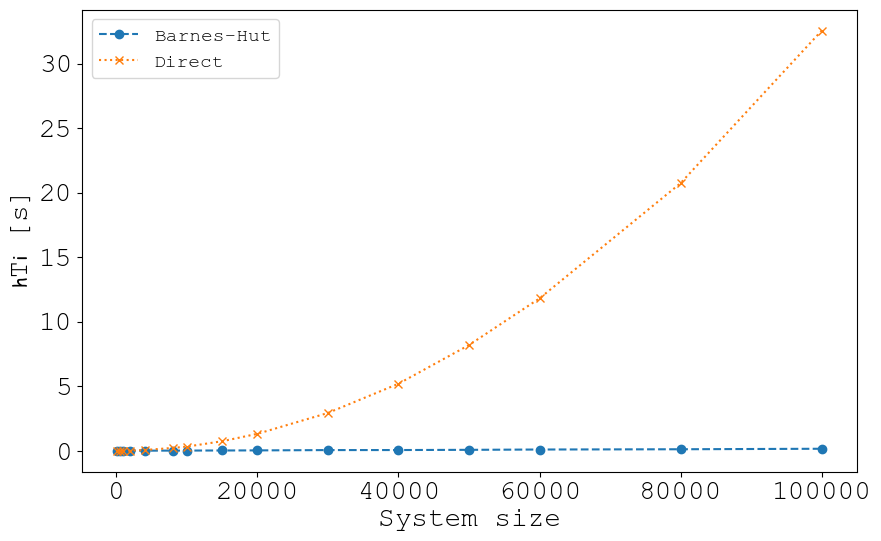

In [196]:
# Plot the data
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(n_particles, bh_time, label='Barnes-Hut',ls = '--', marker='o')
ax.plot(n_particles, direct_time, label='Direct',ls = ':', marker='x')
#ax.plot(x, n_squared, label='$O(n^2)$', linestyle='--', color='gray')
#ax.plot(x, n_log_n, label='$O(n \log n)$', linestyle='--', color='orange')
#ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_xlabel('System size')
ax.set_ylabel(r"$\left< \text{T}\right>$ [s]")
#ax.set_title('Barnes-Hut vs Direct Method Benchmark')
ax.legend(loc='upper left', frameon=True, fontsize = 14)
plt.savefig('../report-presentation/figures/benchmark_results_nolog.png', dpi=300, transparent = True)
plt.show()

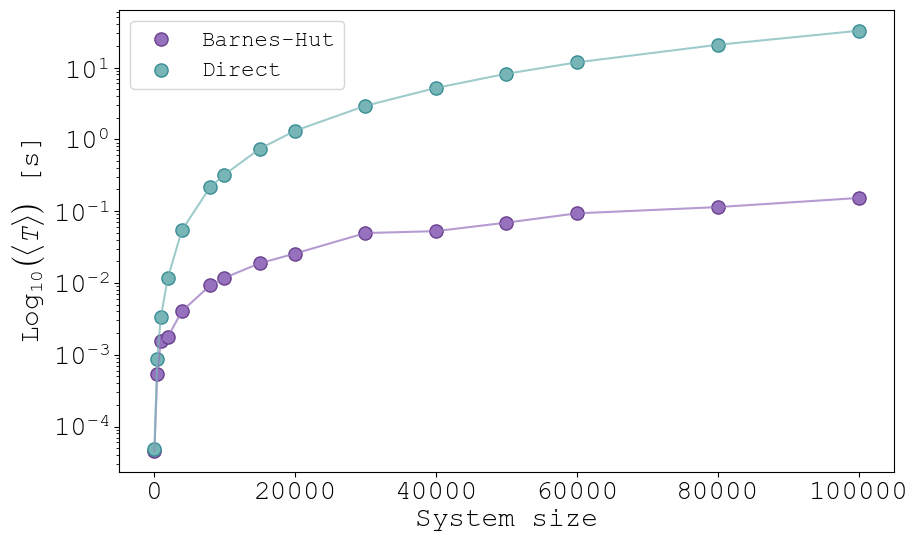

In [265]:
# Plot the data
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(n_particles, bh_time, label = 'Barnes-Hut', color = dataset_colors[0], edgecolors 
           = dataset_line_colors[0], s = 90, marker='o')
ax.scatter(n_particles, direct_time, label = 'Direct', color = dataset_colors[2], edgecolors 
           = dataset_line_colors[2], s = 90, marker='o')
ax.plot(n_particles, bh_time, color = dataset_colors[0], linestyle='-', alpha=0.7)
ax.plot(n_particles, direct_time, color = dataset_colors[2], linestyle='-', alpha=0.7)
ax.set_yscale('log')
ax.set_xlabel('System size')
ax.set_ylabel(r'Log$_{10}$$\left(\langle T \rangle\right)$ [s]')
ax.legend(loc='upper left', frameon=True, fontsize = 16)

plt.savefig('../report-presentation/figures/benchmark_results.pdf')
plt.show()

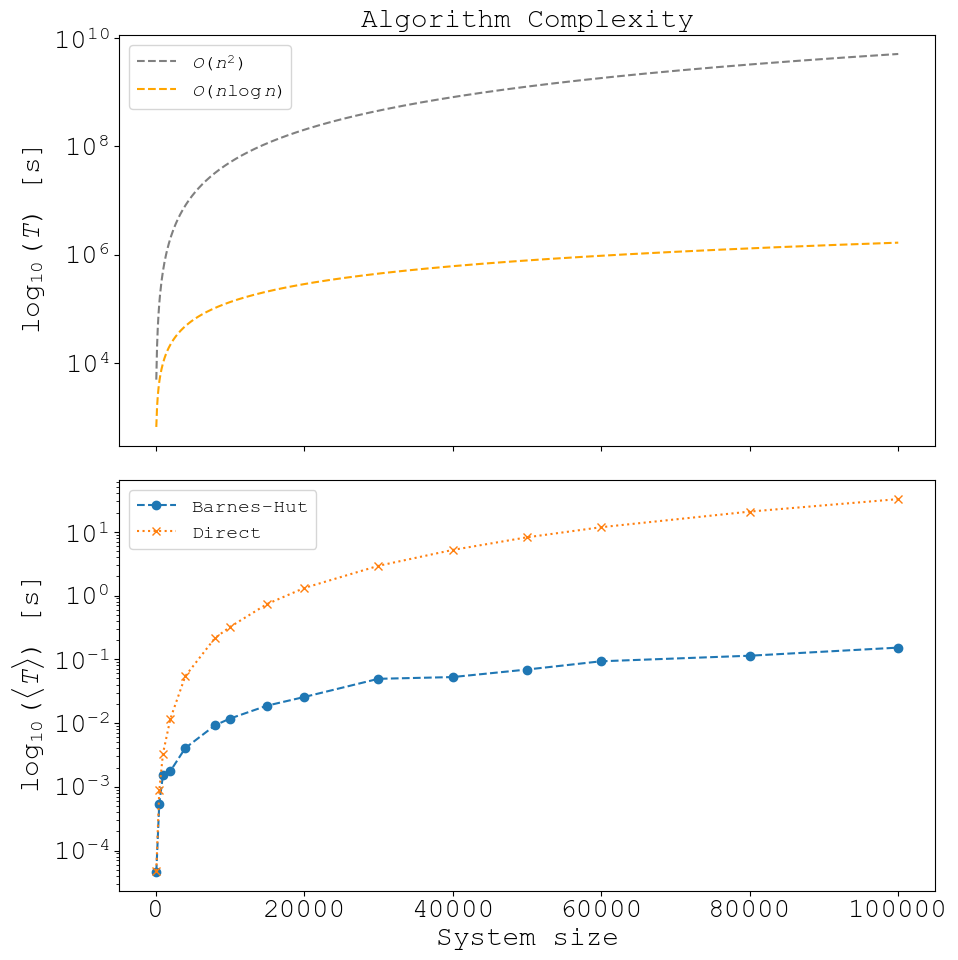

In [212]:
fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# First subplot
axs[0].plot(x, n_squared, label='$O(n^2)$', linestyle='--', color='gray')
axs[0].plot(x, n_log_n, label='$O(n \log n)$', linestyle='--', color='orange')
axs[0].set_ylabel(r'$\log_{10}(T)$ [s]')
axs[0].set_yscale('log')
axs[0].set_title('Algorithm Complexity')
axs[0].legend(loc='upper left', frameon=True, fontsize=14)

# Second subplot
axs[1].plot(n_particles, bh_time, label='Barnes-Hut', ls='--', marker='o')
axs[1].plot(n_particles, direct_time, label='Direct', ls=':', marker='x')
axs[1].set_xlabel('System size')
axs[1].set_ylabel(r'$\log_{10}(\langle T \rangle)$ [s]')
axs[1].set_yscale('log')
axs[1].legend(loc='upper left', frameon=True, fontsize=14)

# Adjust layout to reduce spacing
plt.tight_layout()
plt.savefig('../report-presentation/figures/benchmark_results_complexity_theory.png', dpi=300, transparent=True)
plt.show()


## Energy drift

In [215]:
energy_direct = pd.read_csv('./energy_direct.csv', sep = ',')
energy_bh = pd.read_csv('./energy_bh.csv', sep = ',')

In [267]:
energy_direct['delta_energy'][:52]

0     0.000000
1    -0.001586
2     0.000459
3     0.003545
4     0.009739
5     0.015367
6     0.018060
7     0.017759
8     0.014736
9     0.009553
10    0.003734
11    0.000473
12   -0.003634
13   -0.005868
14   -0.006238
15   -0.003930
16   -0.004241
17    0.001573
18    0.003626
19    0.007783
20    0.014974
21    0.016304
22    0.019834
23    0.012913
24    0.009213
25    0.004587
26    0.003816
27    0.006656
28    0.000774
29   -0.001457
30   -0.003401
31   -0.002444
32   -0.000324
33    0.002906
34    0.002613
35    0.002766
36    0.014721
37    0.009624
38    0.013311
39    0.008708
40    0.008350
41    0.006103
42    0.005950
43    0.001149
44   -0.000499
45    0.006566
46    0.004216
47    0.003525
48    0.003920
49    0.000559
50    0.006654
51    0.008759
Name: delta_energy, dtype: float64

In [270]:
alpha = 51

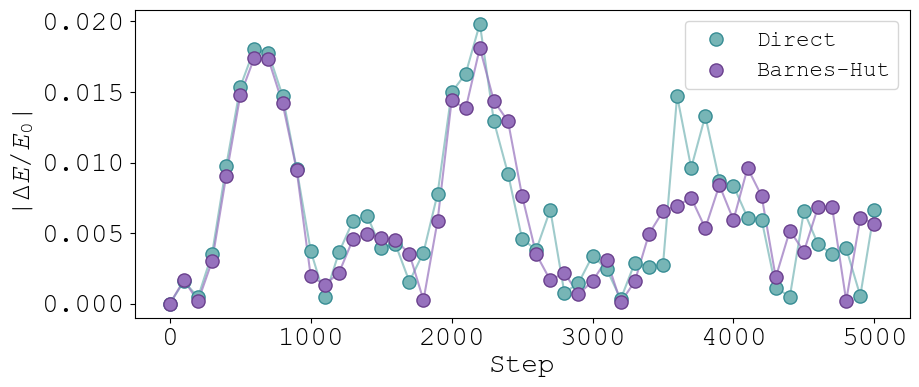

In [271]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(energy_direct['step'][:alpha], abs(energy_direct['delta_energy'][:alpha]), 
           label = 'Direct', color = dataset_colors[2], edgecolors = dataset_line_colors[2], s = 90, marker='o', zorder =3)
ax.scatter(energy_bh['step'][:alpha], abs(energy_bh['delta_energy'][:alpha]), 
           label = 'Barnes-Hut', color = dataset_colors[0], edgecolors = dataset_line_colors[0], s = 90, marker='o', zorder = 3)
ax.plot(energy_direct['step'][:alpha], abs(energy_direct['delta_energy'][:alpha]), 
        color = dataset_colors[2], linestyle='-', alpha=0.7, zorder = 2)
ax.plot(energy_bh['step'][:alpha], abs(energy_bh['delta_energy'][:alpha]), 
        color = dataset_colors[0], linestyle='-', alpha=0.7, zorder = 2)
ax.set_xlabel('Step')
ax.set_ylabel(r'$|\Delta E / E_0|$')


ax.legend(loc='upper right', frameon=True, fontsize=16)
plt.savefig('../report-presentation/figures/energy_conservation.pdf')
plt.show()

## Force errors

In [241]:
# Get the force data
force_direct = pd.read_csv('./forces_direct.csv', sep = ',')
force_bh_5 = pd.read_csv('./forces_bh_5.csv', sep = ',')
force_bh_4 = pd.read_csv('./forces_bh_4.csv', sep = ',')
force_bh_3 = pd.read_csv('./forces_bh_3.csv', sep = ',')
force_bh_2 = pd.read_csv('./forces_bh_2.csv', sep = ',')
force_bh_1 = pd.read_csv('./forces_bh_1.csv', sep = ',')
force_direct

,body_index,force_x,force_y
0,0,4.434480e+03,-3.186480e+03
1,1,-1.103440e+08,1.139280e+08
2,2,3.558600e+07,1.337260e+08
3,3,-6.191300e+06,1.505770e+08
4,4,9.162730e+07,1.167960e+08
...,...,...,...
4995,4995,-6.335030e+04,1.731420e+06
4996,4996,-1.723260e+06,2.359350e+05
4997,4997,3.839400e+05,1.816010e+06
4998,4998,-1.704530e+06,3.577790e+05


In [249]:
def acc_error(exact_force, bh_force):
    exact_x = np.array(exact_force['force_x'])
    exact_y = np.array(exact_force['force_y'])

    approx_x = np.array(bh_force['force_x'])
    approx_y = np.array(bh_force['force_y'])

    mag_exact = np.linalg.norm(np.array([exact_x, exact_y]), axis=0)
    mag_approx = np.linalg.norm(np.array([approx_x, approx_y]), axis=0)

    error = np.mean(np.abs(mag_exact - mag_approx) / mag_exact)
    return error

In [250]:
epsilon_5 = acc_error(force_direct, force_bh_5)
epsilon_4 = acc_error(force_direct, force_bh_4)
epsilon_3 = acc_error(force_direct, force_bh_3)
epsilon_2 = acc_error(force_direct, force_bh_2)
epsilon_1 = acc_error(force_direct, force_bh_1)

In [251]:
error_vec = np.array([epsilon_1, epsilon_2, epsilon_3, epsilon_4, epsilon_5])
theta = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

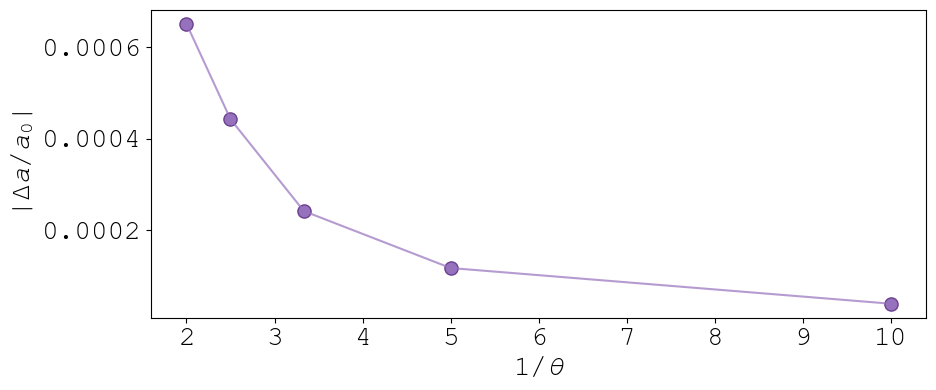

In [262]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(1/theta, error_vec, color = dataset_colors[0], edgecolors = dataset_line_colors[0], s = 90, marker='o')
ax.plot(1/theta, error_vec, color = dataset_colors[0], linestyle='-', alpha=0.7)
ax.set_xlabel(r'$1/\theta$')
ax.set_ylabel(r'$|\Delta a / a_0|$')
plt.savefig('../report-presentation/figures/force_accuracy.pdf')
plt.show()